# Streaming Lars Forward Return

Build LOB features from MBO data, add a forward-return target, then run rolling time-series validation with the streaming `Lars(/Ridge)Adapter`.

In [1]:
# Source - https://stackoverflow.com/a/10472712
# Posted by Andrew_1510, modified by community. See post 'Timeline' for change history
# Retrieved 2026-06-28, License - CC BY-SA 4.0

%load_ext autoreload
%autoreload 2


In [52]:
from __future__ import annotations

import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import polars as pl

from tools.data import DateFrame, RAW_PATH, Raw
from tools.features import LOBFeatures, add_features, depth_meta
from tools.filters import intraday_time, level_taken, tight_spread, trade_size
from tools.model import LarsAdapter, RidgeAdapter
from tools.pipeline import Pipeline
from tools.score import get_unit_pnl, rmse
from tools.price import add_return
from tools.search import loguniform, grid
from tools.transform import Standardizer


In [3]:
from tools.data import expand_dates

expand_dates('20260501-20260507')

['2026-05-01', '2026-05-04', '2026-05-05', '2026-05-06', '2026-05-07']

In [4]:
def divide_dates(*args):
    dates = []
    for i in range(1, len(args)):
        dates.append(expand_dates(f'{args[i - 1]}-{args[i]}', end_date=False if i < len(args) - 1 else True))
    return dates

In [5]:
# divide_dates(20260323, 20260410, 20260425, 20260510, 20260529)

In [6]:
# Data
PROD = "ES"
# ROLLING_DATES = [['2026-05-01', '2026-05-04', '2026-05-05'], ["2026-05-06"], ["2026-05-07"]]
ROLLING_DATES = divide_dates(20260323, 20260410, 20260425, 20260510, 20260528)
TEST_DATES = ["2026-05-29"]
L2_DEPTH = 5
MODEL_BATCH_SIZE = 20_000
POLARS_ENGINE = "streaming"
ORDERBOOK_PATH = str(ROOT / f"data/orderbook_l2_parquet/{{prod}}M6_{{d}}_{{tag}}_{{prod_s}}_full_day_l2_d{L2_DEPTH}.parquet")
RAW_CONTEXT_COLS = ("ts_event", "instrument_id")
# RAW_CONTEXT_COLS = ("ts_event", "ts_recv", "symbol")
REGULAR_HOURS_START = "09:30"
REGULAR_HOURS_END = "16:00"
REGULAR_HOURS_TZ = "America/New_York"

# Feature knobs
IMBALANCE_DEPTHS = [1, 3, 5]
IMBALANCE_LOG = True
TRADE_MOMENTUM_LOG = True
WEIGHTED_PRICE_DEPTH = 5
WEIGHTED_PRICE_SIZES = [2, 5, 10]
TRADE_MOMENTUM_HALF_LIVES = [1, 10, 30, 120]  # seconds

# Forward-return target knobs
FUTURE_HORIZONS = ["10s", "30s", "60s"]
FUTURE_WEIGHTS = [0.5, 0.3, 0.2]
TARGET = "forward_mid_return_bps"
TEST_PNL_THRESHOLD = 0.2

# Lars/search knobs
# SAMPLER = "random"
SAMPLER = "grid"
PATH_EVAL_ALPHAS = np.geomspace(1e-2, 20, 30).tolist()
N_TRIALS = len(PATH_EVAL_ALPHAS)
SEARCH_SPACE = {"alpha": grid(PATH_EVAL_ALPHAS)}
# SEARCH_SPACE = {"alpha": grid([0])}

UNDEF_PRICE = 9_223_372_036_854_775_807
assert L2_DEPTH >= max([*IMBALANCE_DEPTHS, WEIGHTED_PRICE_DEPTH])
TICKSIZE = 250000000

In [7]:
def tag(x: object) -> str:
    return str(x).replace(".", "p")


def feature_exprs() -> dict[str, pl.Expr]:
    exprs = {}
    for depth in IMBALANCE_DEPTHS:
        exprs[f"imb_d{depth}"] = LOBFeatures.book_imbalance(depth, log=IMBALANCE_LOG)
    for size in sorted(set([*WEIGHTED_PRICE_SIZES])):
        exprs[f"weighted_price_sz{tag(size)}"] = LOBFeatures.size_weighted_avg_price(WEIGHTED_PRICE_DEPTH, size)
    for half_life in TRADE_MOMENTUM_HALF_LIVES:
        exprs[f"trade_momentum_hl{tag(half_life)}s"] = LOBFeatures.trade_momentum(half_life, log=TRADE_MOMENTUM_LOG)
    return exprs


FEATURE_EXPRS = feature_exprs()
FEATURES = list(FEATURE_EXPRS)
###
# FEATURES = ["imb_d1"]
# FEATURES = ["weighted_price_sz5"]
###
MID = (pl.col("bid_px_0") + pl.col("ask_px_0")) / 2
# META_COLS = ["ts_event", "ts_recv", "symbol", *depth_meta(L2_DEPTH)]
META_COLS = ["ts_event", "instrument_id", *depth_meta(L2_DEPTH)]
VALID_ROWS = (
    (pl.col("bid_px_0") != UNDEF_PRICE)
    & (pl.col("ask_px_0") != UNDEF_PRICE)
    & (pl.col("ask_px_0") > pl.col("bid_px_0"))
    & pl.col(TARGET).is_not_null()
    & pl.all_horizontal([pl.col(c).is_finite() for c in FEATURES])
)
REGULAR_HOURS = intraday_time(REGULAR_HOURS_START, REGULAR_HOURS_END, timezone=REGULAR_HOURS_TZ)
TIGHT_SPREAD = tight_spread(TICKSIZE)
VALID_REGULAR_ROWS = VALID_ROWS & REGULAR_HOURS & TIGHT_SPREAD
TRAIN_ROWS = VALID_REGULAR_ROWS & (level_taken() | trade_size(0.3))
FEATURES


['imb_d1',
 'imb_d3',
 'imb_d5',
 'weighted_price_sz2',
 'weighted_price_sz5',
 'weighted_price_sz10',
 'trade_momentum_hl1s',
 'trade_momentum_hl10s',
 'trade_momentum_hl30s',
 'trade_momentum_hl120s']

In [8]:
REGULAR_HOURS

<Expr ['[([(col("ts_event").dt.convert…'] at 0x7408938E8AD0>

In [9]:
def raw_context(day: str, prod: str) -> pl.LazyFrame:
    raw_path, _ = Raw.resolve_path(day, prod, RAW_PATH)
    cols = [c for c in RAW_CONTEXT_COLS if c in pl.scan_parquet(raw_path).collect_schema().names()]
    return (
        pl.scan_parquet(raw_path)
        .select(cols)
        .with_row_index("row_nr")
        .with_columns(pl.col("row_nr").cast(pl.UInt64))
    )


def load_orderbook_date(day: str, prod: str = PROD) -> DateFrame:
    book_path, tag = Raw.resolve_path(day, prod, ORDERBOOK_PATH)
    order_cols = ["ts_event", "row_nr"]
    # lf = (
    #     pl.scan_parquet(book_path)
    #     .join(raw_context(day, prod), on="row_nr", how="left")
    #     .sort(order_cols)
    # )
    lf = pl.scan_parquet(book_path)
    lf = add_return(lf, MID, FUTURE_HORIZONS, FUTURE_WEIGHTS, name=TARGET)
    lf = add_features(lf, FEATURE_EXPRS)
    lf = lf.sort(order_cols)
    cols = list(dict.fromkeys([*META_COLS, *FEATURES, TARGET]))
    return DateFrame(day, tag, lf.select(cols))


def loader(dates: list[str]) -> list[DateFrame]:
    return [load_orderbook_date(day) for day in dates]


In [10]:
from tools.data import DataSource

FEATURE_TEST_SCORE = get_unit_pnl(TEST_PNL_THRESHOLD)
FEATURE_TEST_SCORE_DESCENDING = True

test_date_src = DataSource(
    dates=TEST_DATES,
    loader=loader,
    target=TARGET,
    features=FEATURES,
    filters=(VALID_REGULAR_ROWS,),
    polars_engine=POLARS_ENGINE,
)

feature_test_states = dict.fromkeys(FEATURES)
feature_test_rows = 0
for x, y_true, ctx in test_date_src.batches(MODEL_BATCH_SIZE):
    feature_test_rows += int(ctx["n"])
    for idx, feature in enumerate(FEATURES):
        feature_test_states[feature] = FEATURE_TEST_SCORE(
            y_true,
            x[:, idx],
            ctx,
            combine_with=feature_test_states[feature],
        )

feature_test_scores = (
    pl.DataFrame(
        [
            {
                "feature": feature,
                "score": getattr(FEATURE_TEST_SCORE, "__name__", "score"),
                "test_score": float(state),
                "score_n": int(getattr(state, "n", 0)),
                "rows": feature_test_rows,
            }
            for feature, state in feature_test_states.items()
            if state is not None
        ]
    )
    .sort("test_score", descending=FEATURE_TEST_SCORE_DESCENDING)
)

feature_test_scores


feature,score,test_score,score_n,rows
str,str,f64,i64,i64
"""weighted_price_sz2""","""unit_pnl_0.2""",0.745485,75,7090481
"""weighted_price_sz10""","""unit_pnl_0.2""",0.263271,1524,7090481
"""weighted_price_sz5""","""unit_pnl_0.2""",0.251509,664,7090481
"""imb_d5""","""unit_pnl_0.2""",0.102274,5460956,7090481
"""imb_d3""","""unit_pnl_0.2""",0.096959,5825447,7090481
"""imb_d1""","""unit_pnl_0.2""",0.096387,6422252,7090481
"""trade_momentum_hl120s""","""unit_pnl_0.2""",0.049838,3175883,7090481
"""trade_momentum_hl1s""","""unit_pnl_0.2""",-0.07114,6194072,7090481
"""trade_momentum_hl30s""","""unit_pnl_0.2""",-0.115474,4246998,7090481


In [11]:
pipeline = Pipeline(
    rolling_dates=ROLLING_DATES,
    test_dates=TEST_DATES,
    adapter=LarsAdapter(
        batch_size=MODEL_BATCH_SIZE,
        alpha_min=0.0,
        fit_intercept=False,
        path_eval_alphas=PATH_EVAL_ALPHAS,
    ),
    # adapter=RidgeAdapter(batch_size=MODEL_BATCH_SIZE, fit_intercept=False, stats_backend="gpu"),
    target=TARGET,
    features=FEATURES,
    data_loader=loader,
    search_space=SEARCH_SPACE,
    val_score=rmse,
    transform=Standardizer(FEATURES),
    train_filters=(TRAIN_ROWS,),
    val_filters=(VALID_REGULAR_ROWS,),
    test_filters=(VALID_REGULAR_ROWS,),
    sampler=SAMPLER,
    n_trials=N_TRIALS,
    cache_arrays=False,
    score_direction="minimize",
    polars_engine=POLARS_ENGINE,
)
pipeline


Pipeline(rolling_dates=[['2026-03-23', '2026-03-24', '2026-03-25', '2026-03-26', '2026-03-27', '2026-03-30', '2026-03-31', '2026-04-01', '2026-04-02', '2026-04-06', '2026-04-07', '2026-04-08', '2026-04-09'], ['2026-04-10', '2026-04-13', '2026-04-14', '2026-04-15', '2026-04-16', '2026-04-17', '2026-04-20', '2026-04-21', '2026-04-22', '2026-04-23', '2026-04-24'], ['2026-04-27', '2026-04-28', '2026-04-29', '2026-04-30', '2026-05-01', '2026-05-04', '2026-05-05', '2026-05-06', '2026-05-07', '2026-05-08'], ['2026-05-11', '2026-05-12', '2026-05-13', '2026-05-14', '2026-05-15', '2026-05-18', '2026-05-19', '2026-05-20', '2026-05-21', '2026-05-22', '2026-05-26', '2026-05-27', '2026-05-28']], test_dates=['2026-05-29'], adapter=LarsAdapter(alpha=1.0, method='lasso', fit_intercept=False, max_iter=500, alpha_min=0.0, eps=2.220446049250313e-16, positive=False, batch_size=20000, max_features=None, stats_backend='cpu', stats_dtype=<class 'numpy.float64'>, streaming=True, cache_path=True, vectorized_pat

In [12]:
# for d in ROLLING_DATES[0]:
#     src = DataSource(
#         dates=[d],
#         loader=loader,
#         target=TARGET,
#         features=FEATURES,
#         filters=(TRAIN_ROWS,),
#         polars_engine="streaming",
#     )
#     n = sum(len(y) for _, y, _ in src.batches(MODEL_BATCH_SIZE))
#     print(d, n)

In [13]:
ROLLING_DATES[-1][:1]

['2026-05-11']

In [14]:
# from tools.data import DataSource

# src = DataSource(
#     dates=ROLLING_DATES[-1][-1:],
#     loader=loader,
#     target=TARGET,
#     features=FEATURES + ["ts_event", "bid_px_0", "ask_px_0"],
#     filters=(VALID_ROWS,),
#     polars_engine=POLARS_ENGINE,
# )

# df = src.frame()[::1000].collect()
# sprd = 2. * (pl.col('ask_px_0') - pl.col('bid_px_0')) / (pl.col('ask_px_0') + pl.col('bid_px_0')) * 1e4
# print(src.frame().select(sprd).min().collect())
# # src.frame().select(pl.len()).collect()

In [15]:
# df.filter(tight_spread(250000000))

In [16]:
# from matplotlib import pyplot as plt
# import numpy as np
# corr = np.zeros((len(FEATURES), len(FEATURES)))
# for i in range(len(FEATURES)):
#     for j in range(len(FEATURES)):
#         f = FEATURES[i]
#         f1 = FEATURES[j]
#         corr[i, j] = df.select(pl.corr(pl.col(f), pl.col(f1)))[0].item()
# print(corr)
# for f in FEATURES:
#     print(f, df.select(pl.corr(pl.col(f), pl.col(TARGET)), pl.col(TARGET).std()))
#     plt.scatter(df[f], df[TARGET])
#     plt.show()

In [17]:
train_result = pipeline.train(verbose=2)
train_result


/home/jli/projects/rep/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-06-29 19:45:34,619] A new study created in memory with name: no-name-4f1a2369-bf94-4a19-8fb1-a2b8961666a7


======== Optuna study created. Launching optimization.
======== running params {'alpha': 0.016891073086154205}
======== fold: 0, with train = ['2026-03-23', '2026-03-24', '2026-03-25', '2026-03-26', '2026-03-27', '2026-03-30', '2026-03-31', '2026-04-01', '2026-04-02', '2026-04-06', '2026-04-07', '2026-04-08', '2026-04-09'] and val = ['2026-04-10', '2026-04-13', '2026-04-14', '2026-04-15', '2026-04-16', '2026-04-17', '2026-04-20', '2026-04-21', '2026-04-22', '2026-04-23', '2026-04-24']
======== loss = 1.8872590313306108, running average = 1.8872590313306108
======== fold: 1, with train = ['2026-03-23', '2026-03-24', '2026-03-25', '2026-03-26', '2026-03-27', '2026-03-30', '2026-03-31', '2026-04-01', '2026-04-02', '2026-04-06', '2026-04-07', '2026-04-08', '2026-04-09', '2026-04-10', '2026-04-13', '2026-04-14', '2026-04-15', '2026-04-16', '2026-04-17', '2026-04-20', '2026-04-21', '2026-04-22', '2026-04-23', '2026-04-24'] and val = ['2026-04-27', '2026-04-28', '2026-04-29', '2026-04-30', '2

[I 2026-06-30 00:26:47,709] Trial 0 finished with value: 1.8542888039406882 and parameters: {'alpha': 0.016891073086154205}. Best is trial 0 with value: 1.8542888039406882.
[I 2026-06-30 00:26:47,751] Trial 1 finished with value: 1.8566876093154163 and parameters: {'alpha': 15.388680223910978}. Best is trial 0 with value: 1.8542888039406882.
[I 2026-06-30 00:26:47,752] Trial 2 finished with value: 1.8566876093154163 and parameters: {'alpha': 0.3018367159658668}. Best is trial 0 with value: 1.8542888039406882.
[I 2026-06-30 00:26:47,754] Trial 3 finished with value: 1.8560132978384782 and parameters: {'alpha': 0.13749477839988802}. Best is trial 0 with value: 1.8542888039406882.
[I 2026-06-30 00:26:47,755] Trial 4 finished with value: 1.8566876093154163 and parameters: {'alpha': 9.110540310505934}. Best is trial 0 with value: 1.8542888039406882.
[I 2026-06-30 00:26:47,773] Trial 5 finished with value: 1.8566876093154163 and parameters: {'alpha': 5.3937013143196575}. Best is trial 0 with

======== loss = 1.9577033686823715, running average = 1.8542888039406882
======== running params {'alpha': 15.388680223910978}
======== fold: 0, with train = ['2026-03-23', '2026-03-24', '2026-03-25', '2026-03-26', '2026-03-27', '2026-03-30', '2026-03-31', '2026-04-01', '2026-04-02', '2026-04-06', '2026-04-07', '2026-04-08', '2026-04-09'] and val = ['2026-04-10', '2026-04-13', '2026-04-14', '2026-04-15', '2026-04-16', '2026-04-17', '2026-04-20', '2026-04-21', '2026-04-22', '2026-04-23', '2026-04-24']
======== loss = 1.8898068884499006, running average = 1.8898068884499006
======== fold: 1, with train = ['2026-03-23', '2026-03-24', '2026-03-25', '2026-03-26', '2026-03-27', '2026-03-30', '2026-03-31', '2026-04-01', '2026-04-02', '2026-04-06', '2026-04-07', '2026-04-08', '2026-04-09', '2026-04-10', '2026-04-13', '2026-04-14', '2026-04-15', '2026-04-16', '2026-04-17', '2026-04-20', '2026-04-21', '2026-04-22', '2026-04-23', '2026-04-24'] and val = ['2026-04-27', '2026-04-28', '2026-04-29', 

{'best_params': {'alpha': 0.012996566118076808},
 'best_score': 1.8542680114994177,
 'n_trials': 30,
 'validation_history': [{'trial': 0,
   'fold': 0,
   'val_score': 1.8872590313306108,
   'weighted_score': 1.8872590313306108,
   'n': 85053718,
   'dates': ['2026-04-10',
    '2026-04-13',
    '2026-04-14',
    '2026-04-15',
    '2026-04-16',
    '2026-04-17',
    '2026-04-20',
    '2026-04-21',
    '2026-04-22',
    '2026-04-23',
    '2026-04-24'],
   'natures': ['stress', 'normal'],
   'params': {'alpha': 0.016891073086154205}},
  {'trial': 0,
   'fold': 1,
   'val_score': 1.632942909732898,
   'weighted_score': 1.7579333782078996,
   'n': 69848608,
   'dates': ['2026-04-27',
    '2026-04-28',
    '2026-04-29',
    '2026-04-30',
    '2026-05-01',
    '2026-05-04',
    '2026-05-05',
    '2026-05-06',
    '2026-05-07',
    '2026-05-08'],
   'natures': ['extra_normal', 'stress', 'normal'],
   'params': {'alpha': 0.016891073086154205}},
  {'trial': 0,
   'fold': 2,
   'val_score': 1.957

In [18]:
test_result = pipeline.test(get_unit_pnl(0.0))
test_result


{'test_score': 0.08624194719716927,
 'n': 7090481,
 'ctx': {'n': 7090481,
  'dates': ['2026-05-29'],
  'natures': ['extra_normal'],
  'n_active': 7090481,
  'fold': 'test'},
 'y_pred': array([ 0.00233306,  0.00626308,  0.00626308, ..., -0.0244161 ,
        -0.02449093, -0.02459059], shape=(7090481,))}

In [53]:
test_result = pipeline.test(get_unit_pnl(0.1, power=2))
test_result 


{'test_score': 92.32054397788133,
 'n': 7090481,
 'ctx': {'n': 7090481,
  'dates': ['2026-05-29'],
  'natures': ['extra_normal'],
  'n_active': 1621459,
  'fold': 'test'},
 'y_pred': array([ 0.00233306,  0.00626308,  0.00626308, ..., -0.0244161 ,
        -0.02449093, -0.02459059], shape=(7090481,))}

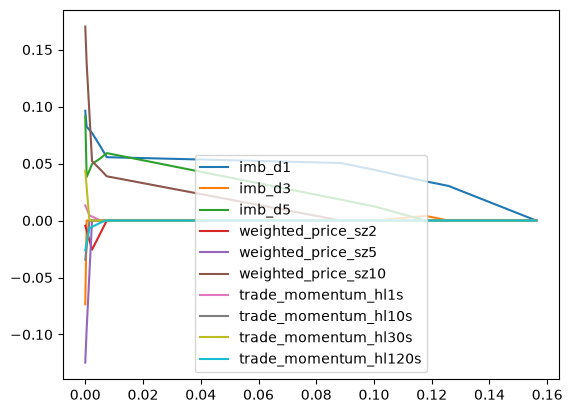

In [55]:
model = pipeline.get_model()
for i in range(model.coefs_path.shape[0]):
    plt.plot(model.alphas, model.coefs_path[i,:], label = FEATURES[i])
plt.legend()

0.001441775620790549 0.08139187069848208


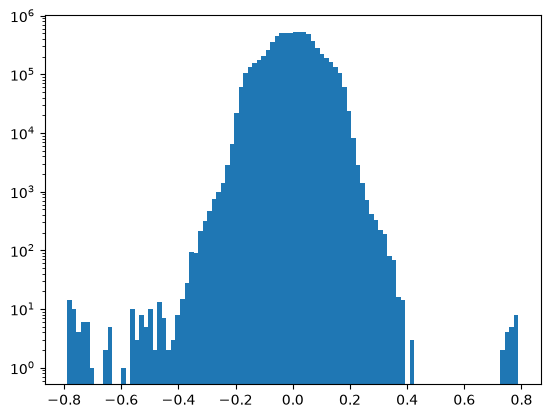

In [56]:
# path = pipeline.adapter.path(pipeline.model)
# {k: (v.shape if hasattr(v, "shape") else len(v)) for k, v in path.items()}
from matplotlib import pyplot as plt
print(np.mean(test_result['y_pred']), np.std(test_result['y_pred']))
_ = plt.hist(test_result['y_pred'], bins=100, log=True, density=False)

In [23]:
model = pipeline.get_model()
transform = pipeline.fitted_transform

if model is None or model.coef is None:
    raise RuntimeError("Run pipeline.train() before inspecting coefficients.")
if transform is None or transform.means is None or transform.stds is None:
    raise RuntimeError("Run pipeline.train() with a fitted Standardizer before inspecting real coefficients.")

features = list(pipeline.features)
raw_coef = [float(coef) for coef in model.coef]
means = [float(transform.means[feature]) for feature in features]
stds = [float(transform.stds[feature]) for feature in features]
real_coef = [coef / std for coef, std in zip(raw_coef, stds)]

raw_intercept = float(model.intercept)
real_intercept = raw_intercept - sum(
    coef * mean / std for coef, mean, std in zip(raw_coef, means, stds)
)

df_coef = pl.DataFrame(
    [
        {
            "term": "intercept",
            "raw_coef": raw_intercept,
            "real_coef": real_intercept,
            "standardizer_mean": None,
            "standardizer_std": None,
        },
        *[
            {
                "term": feature,
                "raw_coef": raw,
                "real_coef": real,
                "standardizer_mean": mean,
                "standardizer_std": std,
            }
            for feature, raw, real, mean, std in zip(features, raw_coef, real_coef, means, stds)
        ],
    ]
)


In [41]:
with pl.Config(tbl_rows=-1):
    display(df_coef)

term,raw_coef,real_coef,standardizer_mean,standardizer_std
str,f64,f64,f64,f64
"""intercept""",0.0,0.001171,null,null
"""imb_d1""",0.055227,0.019093,0.00114,2.892452
"""imb_d3""",0.0,0.0,-0.014513,0.96074
"""imb_d5""",0.056369,0.075913,-0.017045,0.742547
"""weighted_price_sz2""",0.0,0.0,0.000109,0.059278
"""weighted_price_sz5""",0.0,0.0,0.000331,0.109111
"""weighted_price_sz10""",0.036165,0.266518,0.00038,0.135694
"""trade_momentum_hl1s""",0.0,0.0,0.004874,1.400186
"""trade_momentum_hl10s""",0.0,0.0,-0.003431,0.598055


In [25]:
np.std(test_result["y_pred"])

np.float64(0.08139187069848208)